Import the nesscery libraries


In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_excel("Genenome_data.xlsx")
df.head()

,ID,adj.P.Val,P.Value,t,B,logFC,gene_assignment,SPOT_ID,Genes_Symbol
0,TC05002209.hg.1,1,0.000028,5.06,0.2926,1.070,--- // --- // linc-UBE2QL1 chr5:+:5688510-5694...,chr5(+):5688511-5701975,---
1,TC01006233.hg.1,1,0.000052,4.83,-0.0229,0.620,--- // --- // accn=AK000933 class=mRNAlike lnc...,chr1(-):241792155-241794724,---
2,TC12000193.hg.1,1,0.000063,4.75,-0.1260,0.419,NM_018179 // ATF7IP // activating transcriptio...,chr12(+):14518611-14651697,ATF7IP
3,TC14000316.hg.1,1,0.000121,4.51,-0.4650,0.201,NM_001130851 // CDKN3 // cyclin-dependent kina...,chr14(+):54863673-54886936,CDKN3
4,TC12002361.hg.1,1,0.000174,-4.37,-0.6576,-0.282,--- // --- // accn=AF517110 class=mRNAlike lnc...,chr12(+):52282353-52282602,---


In [3]:
df["Genes_Symbol"] = df["Genes_Symbol"].replace("---", "No Annotation")

# (اختياري) إذا أردتِ استبدالها أيضاً في العمود الرئيسي gene_assignment
df["gene_assignment"] = df["gene_assignment"].replace("---", "No Annotation")

# 3. دالة التصنيف
def get_regulation(row):
  if row["P.Value"] < p_cutoff:
    if row["logFC"] > 0:
      return "Upregulated"
    elif row["logFC"] < 0:
      return "Downregulated"
  return "Not Significant"

# 2. حد P-Value المطلوب
p_cutoff = 0.05

# 4. إضافة العمود للجدول
df["Regulated"] = df.apply(get_regulation, axis=1)

# 3. حفظ الداتا المنظفة في ملف إكسل جديد
df.to_excel("Genenome_data_cleaned.xlsx", index=False)

print("تم تعديل الداتا وحفظ الملف الجديد باسم Genenome_data_cleaned.xlsx")

تم تعديل الداتا وحفظ الملف الجديد باسم Genenome_data_cleaned.xlsx


In [4]:
df = pd.read_excel("Genenome_data_cleaned.xlsx")
df.head()

,ID,adj.P.Val,P.Value,t,B,logFC,gene_assignment,SPOT_ID,Genes_Symbol,Regulated
0,TC05002209.hg.1,1,0.000028,5.06,0.2926,1.070,--- // --- // linc-UBE2QL1 chr5:+:5688510-5694...,chr5(+):5688511-5701975,No Annotation,Upregulated
1,TC01006233.hg.1,1,0.000052,4.83,-0.0229,0.620,--- // --- // accn=AK000933 class=mRNAlike lnc...,chr1(-):241792155-241794724,No Annotation,Upregulated
2,TC12000193.hg.1,1,0.000063,4.75,-0.1260,0.419,NM_018179 // ATF7IP // activating transcriptio...,chr12(+):14518611-14651697,ATF7IP,Upregulated
3,TC14000316.hg.1,1,0.000121,4.51,-0.4650,0.201,NM_001130851 // CDKN3 // cyclin-dependent kina...,chr14(+):54863673-54886936,CDKN3,Upregulated
4,TC12002361.hg.1,1,0.000174,-4.37,-0.6576,-0.282,--- // --- // accn=AF517110 class=mRNAlike lnc...,chr12(+):52282353-52282602,No Annotation,Downregulated


Q1

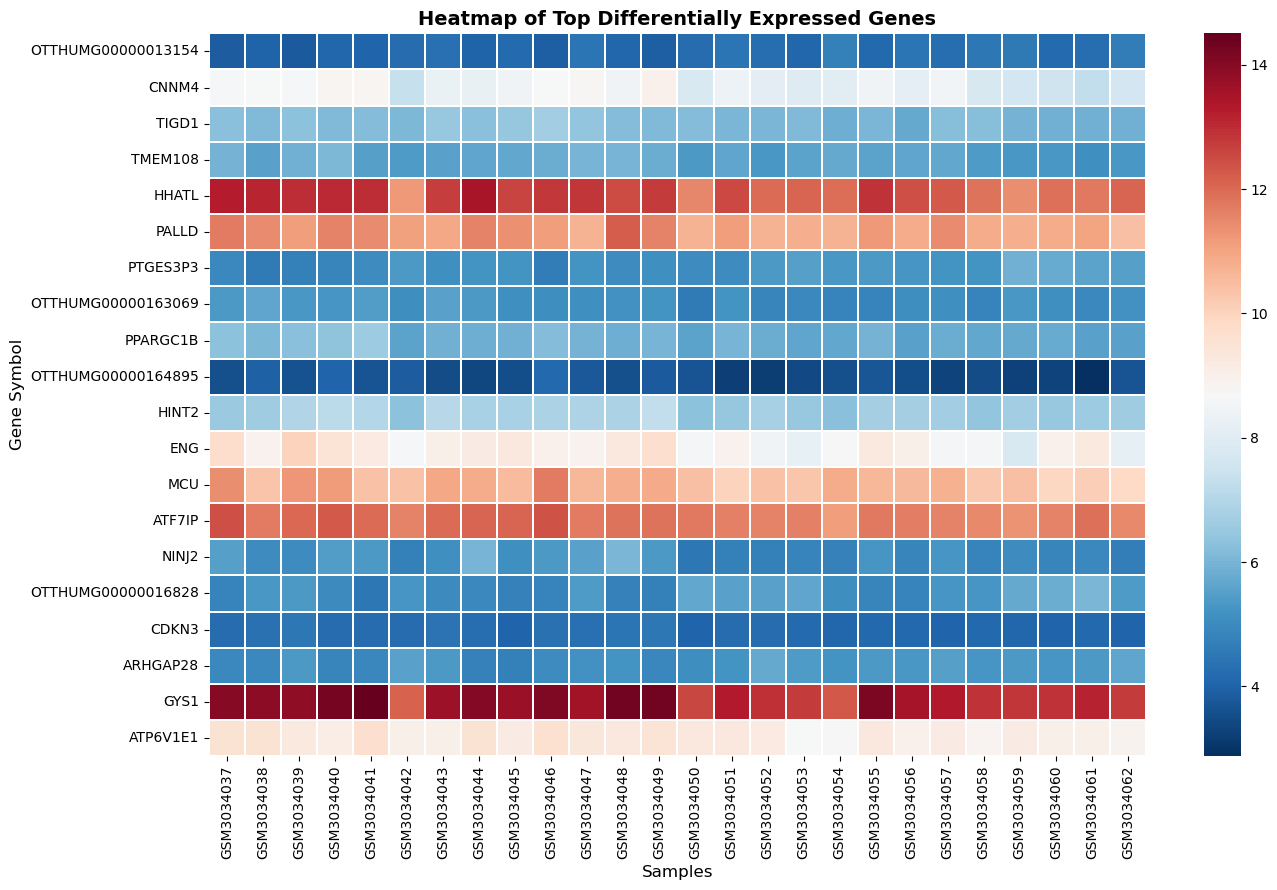

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# تصفية الجينات المحددة فقط وأخذ أفضل 20 جين بناءً على P.Value
valid_genes = df[df["Genes_Symbol"] != "No Annotation"].sort_values(
    "P.Value"
)

# إنشاء قاموس لربط كود الـ ID باسم الجين (Genes_Symbol)
id_to_gene = dict(zip(valid_genes["ID"], valid_genes["Genes_Symbol"]))

# قائمة بالـ IDs الخاصة بأعلى 20 جين
top_ids = list(valid_genes["ID"].head(20))

# ----------------------------
# 2. قراءة ملف Series Matrix
# ----------------------------
matrix = pd.read_csv(
    "GSE111551_series_matrix.txt", sep="\t", skiprows=67
)

# إزالة آخر سطر من التذييل إذا كان موجوداً
matrix = matrix[matrix["ID_REF"] != "!series_matrix_table_end"]

# ----------------------------
# 3. تصفية البيانات واستبدال الـ ID باسم الجين
# ----------------------------
heatmap_df = matrix[matrix["ID_REF"].isin(top_ids)].copy()

# تغيير الـ ID_REF إلى اسم الجين المترجم
heatmap_df["Gene_Name"] = heatmap_df["ID_REF"].map(
    lambda x: id_to_gene.get(x, x)
)

# تعيين أسماء الجينات كـ Index وإلغاء عمود الـ ID_REF
heatmap_df = heatmap_df.set_index("Gene_Name")
heatmap_df = heatmap_df.drop(columns=["ID_REF"])

# تحويل قيم التعبير الجيني إلى أرقام float
heatmap_df = heatmap_df.astype(float)

# ----------------------------
# 4. رسم الـ Heatmap بأسماء الجينات الظاهرة
# ----------------------------
plt.figure(figsize=(14, 9))

sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",
    linewidths=0.3,
    yticklabels=True,  # إظهار جميع أسماء الجينات على المحور
)

plt.title(
    "Heatmap of Top Differentially Expressed Genes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Gene Symbol", fontsize=12)

plt.tight_layout()
plt.show()

Q2

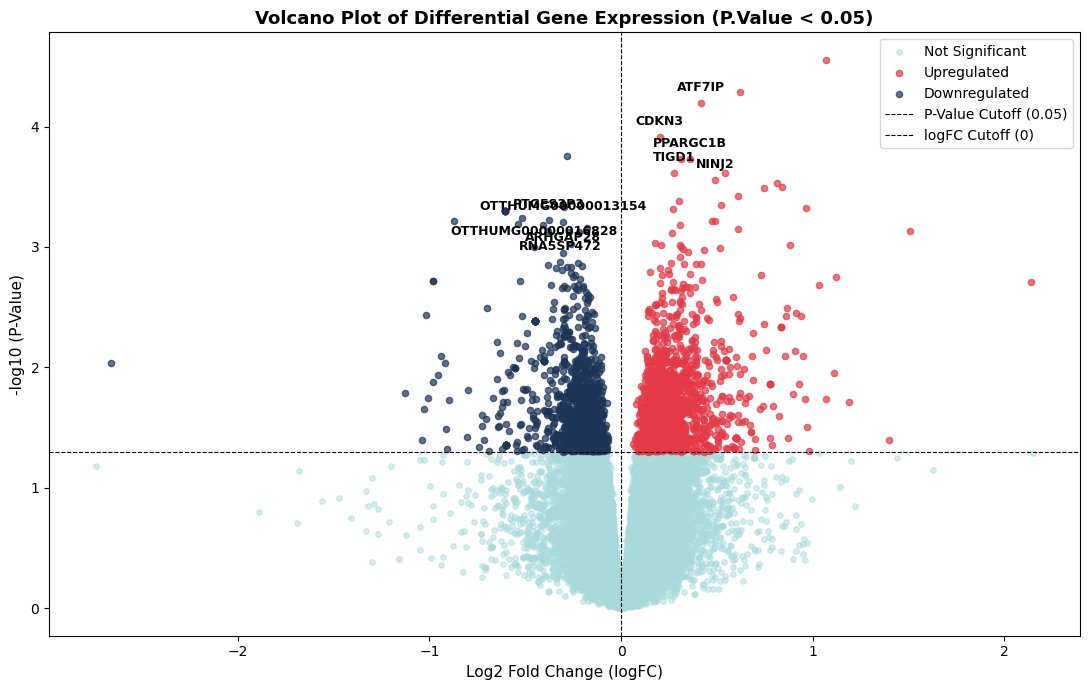

In [6]:
# 2. حساب -log10(P.Value)
df["-log10(P.Value)"] = -np.log10(df["P.Value"])

# 3. إعداد إطار الرسم
plt.figure(figsize=(11, 7))

# 4. فصل البيانات ورسم كل فئة بشكل مستمر ومستقل
ns = df[df["Regulated"] == "Not Significant"]
up = df[df["Regulated"] == "Upregulated"]
down = df[df["Regulated"] == "Downregulated"]

# رسم النقاط (الأزرق الفاتح للغير هام، الأحمر للمرتفع، الكحلي للمنخفض)
plt.scatter(
    ns["logFC"],
    ns["-log10(P.Value)"],
    color="#A8DADC",
    alpha=0.5,
    s=15,
    label="Not Significant",
)
plt.scatter(
    up["logFC"],
    up["-log10(P.Value)"],
    color="#E63946",
    alpha=0.7,
    s=20,
    label="Upregulated",
)
plt.scatter(
    down["logFC"],
    down["-log10(P.Value)"],
    color="#1D3557",
    alpha=0.7,
    s=20,
    label="Downregulated",
)

# 5. إضافة خطوط القطع (Cutoff Lines)
p_cutoff = 0.05
plt.axhline(
    y=-np.log10(p_cutoff),
    color="black",
    linestyle="--",
    linewidth=0.8,
    label=f"P-Value Cutoff ({p_cutoff})",
)
plt.axvline(
    x=0, color="black", linestyle="--", linewidth=0.8, label="logFC Cutoff (0)"
)

# 6. كتابة أسماء أبرز الجينات في الطرفين (مع استبعاد No Annotation)
invalid_names = ["No Annotation", "(No Annotated Gene Symbol)", "---"]

top_up = (
    up[~up["Genes_Symbol"].isin(invalid_names)].sort_values("P.Value").head(5)
)
top_down = (
    down[~down["Genes_Symbol"].isin(invalid_names)]
    .sort_values("P.Value")
    .head(5)
)

for _, row in pd.concat([top_up, top_down]).iterrows():
  plt.text(
      row["logFC"],
      row["-log10(P.Value)"] + 0.1,
      str(row["Genes_Symbol"]),
      fontsize=9,
      ha="center",
      weight="bold",
  )

# 7. العناوين والمحاور
plt.title(
    "Volcano Plot of Differential Gene Expression (P.Value < 0.05)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Log2 Fold Change (logFC)", fontsize=11)
plt.ylabel("-log10 (P-Value)", fontsize=11)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Q3


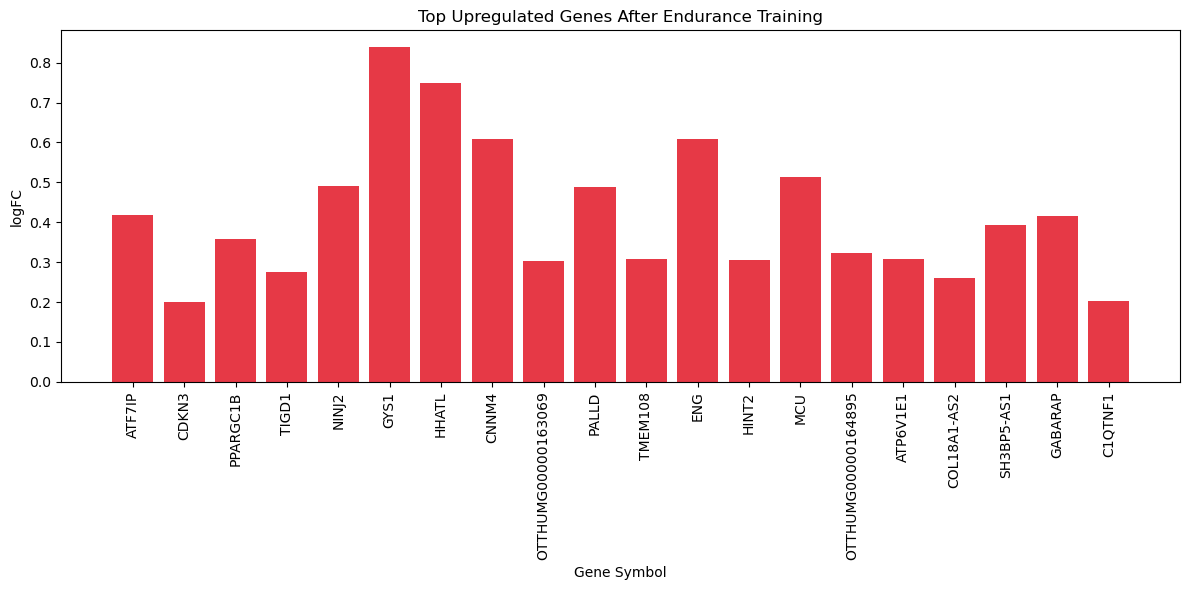

In [7]:
df = df[~df["Genes_Symbol"].isin(["No Annotation", "---"])]

# ترتيب حسب P.Value
df = df.sort_values("P.Value")

# اختيار الجينات التي logFC لها موجب فقط (Upregulated)
df = df[df["logFC"] > 0]

# أخذ أفضل 20 جين حقيقي
top20 = df.head(20)

# ----------------------------
# الرسم البياني
# ----------------------------
plt.figure(figsize=(12, 6))

plt.bar(top20["Genes_Symbol"], top20["logFC"], color="#E63946")

plt.xticks(rotation=90)

plt.xlabel("Gene Symbol")
plt.ylabel("logFC")
plt.title("Top Upregulated Genes After Endurance Training")

plt.tight_layout()
plt.show()

Q4

In [9]:
# قراءة البيانات من شيت string_interactions_short
df = pd.read_excel('Genenome_data_cleaned.xlsx', sheet_name='string_interactions_short')

# عرض أول 10 تفاعلات بروتينية
print(df[['#node1', 'node2', 'coexpression', 'experimentally_determined_interaction', 'combined_score']].head(10))

# استخراج أكثر البروتينات ارتباطاً (Hub Proteins)
hub_genes = pd.concat([df['#node1'], df['node2']]).value_counts()
print("\nTop Connected Genes (Hub Genes):")
print(hub_genes.head(10))

     #node1     node2  coexpression  experimentally_determined_interaction  \
0    AKAIN1  ARHGAP28         0.000                                  0.000   
1  ARHGAP28    MAP6D1         0.000                                  0.000   
2  ARHGAP28   C3orf36         0.000                                  0.000   
3  ARHGAP28     NINJ2         0.000                                  0.000   
4    ATF7IP     CDKN3         0.000                                  0.092   
5    ATF7IP       ENG         0.000                                  0.000   
6    ATF7IP    SPDYE6         0.000                                  0.000   
7    ATF7IP    ZNF883         0.000                                  0.053   
8  ATP6V1E1     TLDC2         0.000                                  0.626   
9  ATP6V1E1       MLX         0.254                                  0.000   

   combined_score  
0           0.541  
1           0.420  
2           0.398  
3           0.292  
4           0.162  
5           0.156  
6

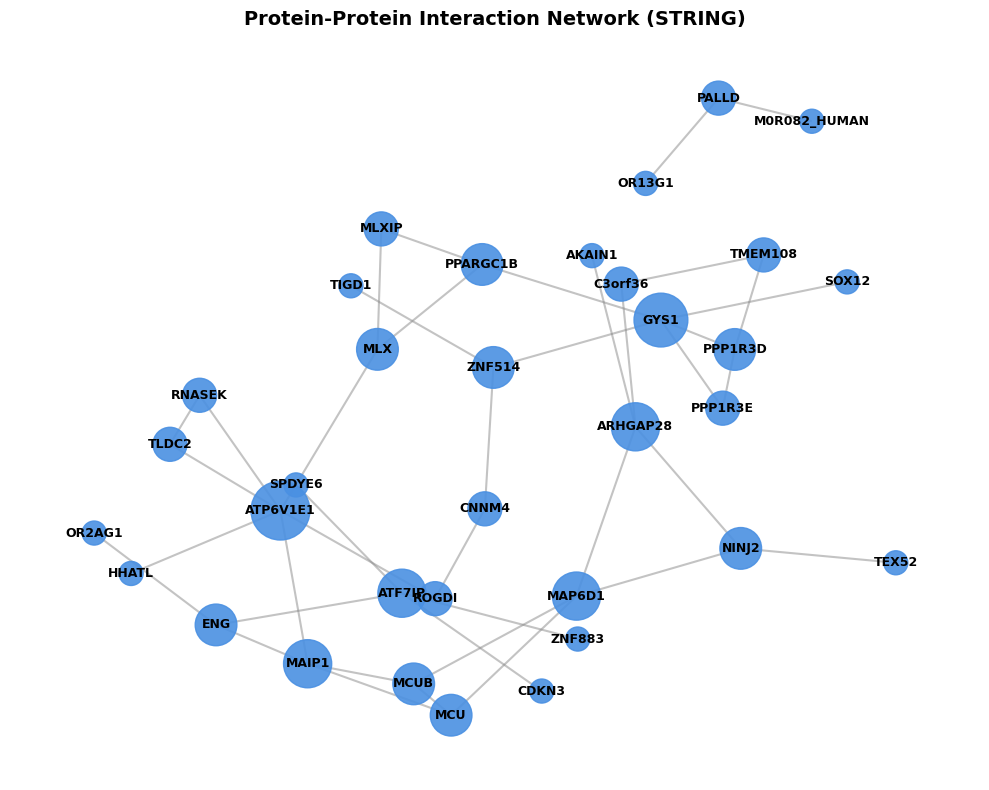

In [10]:
# 1. قراءة البيانات
df = pd.read_excel(
    'Genenome_data_cleaned.xlsx', sheet_name='string_interactions_short'
)

# 2. بناء الرسم البياني
G = nx.from_pandas_edgelist(
    df, source='#node1', target='node2', edge_attr='combined_score'
)

# 3. تحديد أبعاد ومواقع الجينات
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# حجم العقدة بناءً على عدد الروابط
degrees = dict(G.degree())
node_sizes = [v * 300 for v in degrees.values()]

# رسم الجينات والروابط
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color='#4A90E2', alpha=0.9
)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color='#888888')
nx.draw_networkx_labels(
    G, pos, font_size=9, font_family='sans-serif', font_weight='bold'
)

plt.title(
    'Protein-Protein Interaction Network (STRING)',
    fontsize=14,
    fontweight='bold',
)
plt.axis('off')
plt.tight_layout()
plt.show()

C:\Users\althe\AppData\Local\Temp\ipykernel_7892\2348669133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=deg_df.head(10), x='Degree', y='Gene', palette='viridis')


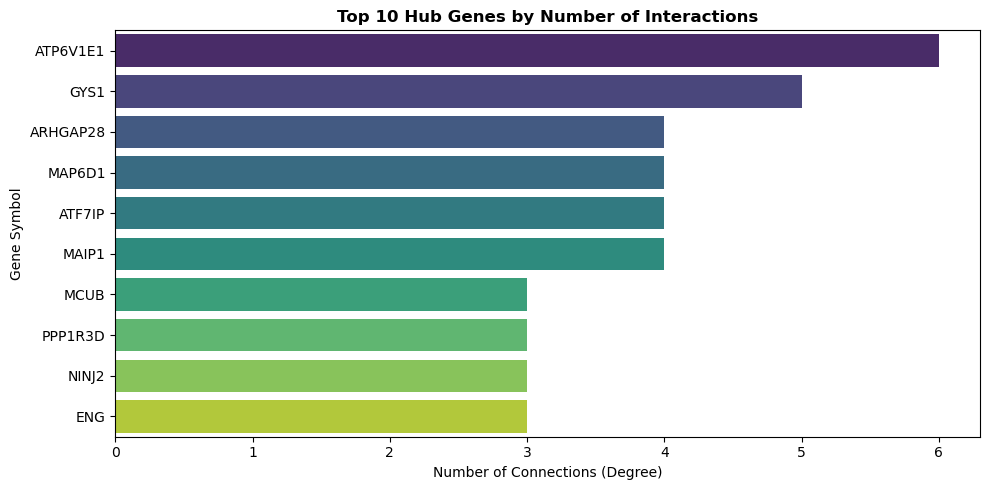

In [11]:
# حساب عدد الروابط لكل جين
degrees = dict(G.degree())
deg_df = pd.DataFrame(list(degrees.items()), columns=['Gene', 'Degree']).sort_values('Degree', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=deg_df.head(10), x='Degree', y='Gene', palette='viridis')
plt.title('Top 10 Hub Genes by Number of Interactions', fontsize=12, fontweight='bold')
plt.xlabel('Number of Connections (Degree)', fontsize=10)
plt.ylabel('Gene Symbol', fontsize=10)
plt.tight_layout()
plt.show()

Q5

Number of samples: 26
Number of expression features: 70523
          PC1        PC2      Condition      Sample
0   33.801532  19.501734   Pre-Training  GSM3034037
1   35.040873  -8.726824   Pre-Training  GSM3034038
2   29.596886  13.218987   Pre-Training  GSM3034039
3   37.053973   2.737754   Pre-Training  GSM3034040
4   38.355974  12.582943   Pre-Training  GSM3034041
5   10.621079   1.834468   Pre-Training  GSM3034042
6  -29.771752   5.876997   Pre-Training  GSM3034043
7  -24.712103  23.831510   Pre-Training  GSM3034044
8  -29.669895  18.259556   Pre-Training  GSM3034045
9  -26.746090  10.084960   Pre-Training  GSM3034046
10 -27.426208 -19.009975   Pre-Training  GSM3034047
11 -20.559866   0.024381   Pre-Training  GSM3034048
12 -17.916673 -16.118981   Pre-Training  GSM3034049
13  21.967588  24.971652  Post-Training  GSM3034050
14  19.990062  17.001994  Post-Training  GSM3034051
15  29.526544 -12.242349  Post-Training  GSM3034052
16  18.273221   4.560833  Post-Training  GSM3034053
17  5

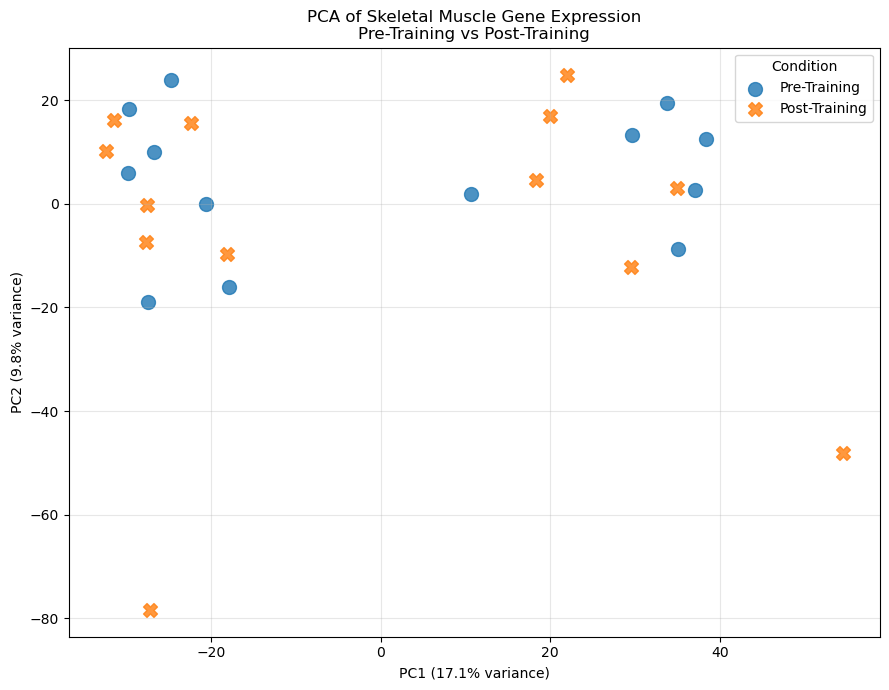

In [12]:

# ==========================================
# 1. Read the REAL Series Matrix
# ==========================================

matrix = pd.read_csv(
    "GSE111551_series_matrix.txt",
    sep="\t",
    skiprows=67
)

# Remove footer if present
matrix = matrix[
    matrix["ID_REF"] != "!series_matrix_table_end"
].copy()

# ==========================================
# 2. Set ID_REF as gene/probe identifier
# ==========================================

matrix = matrix.set_index("ID_REF")

# Convert expression values to numbers
matrix = matrix.apply(pd.to_numeric, errors="coerce")

# Remove rows containing missing values
matrix = matrix.dropna()

# ==========================================
# 3. Transpose the matrix
#
# Before:
# rows = genes
# columns = samples
#
# PCA needs:
# rows = samples
# columns = genes
# ==========================================

X = matrix.T

print("Number of samples:", X.shape[0])
print("Number of expression features:", X.shape[1])

# ==========================================
# 4. Create the REAL sample groups
#
# GSE111551:
# first 13 = Pre-training
# next 13  = Post-training
# ==========================================

conditions = (
    ["Pre-Training"] * 13 +
    ["Post-Training"] * 13
)

# Safety check
assert len(conditions) == X.shape[0], \
    "Sample number is not 26. Check the Series Matrix."

# ==========================================
# 5. Optional but recommended:
# Keep the most variable expression features
#
# This removes thousands of nearly
# uninformative features.
# ==========================================

variances = X.var(axis=0)

top_features = variances.nlargest(5000).index

X_filtered = X[top_features]

# ==========================================
# 6. Standardize the expression values
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_filtered)

# ==========================================
# 7. PCA
# ==========================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

# Percentage of variance explained
pc1_variance = pca.explained_variance_ratio_[0] * 100
pc2_variance = pca.explained_variance_ratio_[1] * 100

# ==========================================
# 8. Create PCA results table
# ==========================================

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Condition": conditions,
    "Sample": X.index
})

print(pca_df)

# ==========================================
# 9. Plot PCA
# ==========================================

plt.figure(figsize=(9, 7))

for condition, marker in [
    ("Pre-Training", "o"),
    ("Post-Training", "X")
]:

    subset = pca_df[
        pca_df["Condition"] == condition
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=condition,
        marker=marker,
        s=100,
        alpha=0.8
    )

plt.xlabel(
    f"PC1 ({pc1_variance:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pc2_variance:.1f}% variance)"
)

plt.title(
    "PCA of Skeletal Muscle Gene Expression\n"
    "Pre-Training vs Post-Training"
)

plt.legend(title="Condition")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()